# This notebook provides a step-by-step guide for constructing a PES for cyclopentadiene dimerization using this method.
 Please ensure that **data.xlsx** is placed in the same directory as this notebook before you begin.

In [9]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import os
import re

The following scripts process the **data.xlsx** file using principal component analysis (PCA). They generate two outputs: **a text file** and **a PCA figure**.

The text file contains the **PCA coefficients**, the **mean values** (used because PCA operates on mean-centered data), and **two additional GIC lines** that can be copied directly into a Gaussian input file for the scan calculation. The **PC1** and **PC2** values correspond directly to the **x-** and **y-axis coordinates** in the PCA figure.The figure shows the locations of all stationary points on the PCA map.

This functionality is identical to what is provided in **pca_input_generate.py**.

Coefficient:
[0.8108 0.4138 0.4138]
[ 0.     -0.7071  0.7071]

Mean_values:
(6,12)    3.8164
(3,8)     5.2414
(5,17)    5.2414
dtype: float64

GIC additional line:
PC1()=(0.8108)*(R(6,12)-3.8164)+(0.4138)*(R(3,8)-5.2414)+(0.4138)*(R(5,17)-5.2414)
PC2()=(0.0)*(R(6,12)-3.8164)+(-0.7071)*(R(3,8)-5.2414)+(0.7071)*(R(5,17)-5.2414)


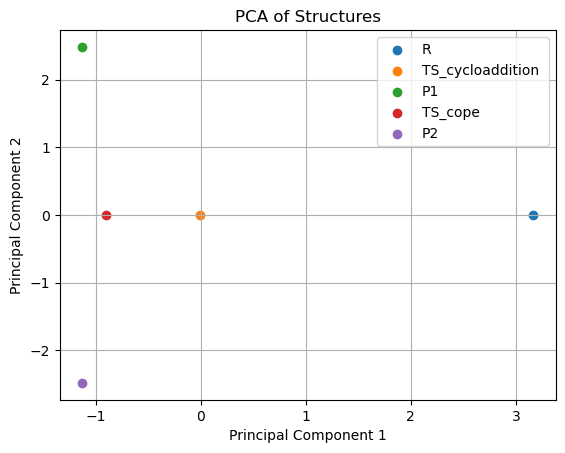

In [8]:
# apply PCA to the data. 
def main():
    
    data = pd.read_excel("data.xlsx")
    labels = data['Unnamed: 0']
    numeric_data = data.drop(columns = ['Unnamed: 0'])

    mean_values = np.around(numeric_data.mean(), decimals=4) #calculate the mean 

    # Apply PCA analysis
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(numeric_data)

    # Create a new DataFrame with the PCA results
    pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
    pca_df['label'] = labels
    coefficients = np.around(pca.components_, decimals=4) # Generate PCA coefficient

    #Save the plot
    plt.figure()
    for label in pca_df['label'].unique():
        subset = pca_df[pca_df['label'] == label]
        plt.scatter(subset['PC1'], subset['PC2'], label=label)

    plt.title('PCA of Structures')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plot_path = "PCA_plot.png"
    plt.savefig(plot_path, dpi=300) 

    # Generate addition Gaussian input line
    output_PC1 = "PC1()=" + "+".join(
        [f"({coeff})*(R{col}-{mean})" for coeff, col, mean in zip(coefficients[0], numeric_data.columns, mean_values)]
    )

    output_PC2 = "PC2()=" + "+".join(
        [f"({coeff})*(R{col}-{mean})" for coeff, col, mean in zip(coefficients[1], numeric_data.columns, mean_values)]
    )

    # Save results to pca_results.txt
    output_file_path = "pca_results.txt"
    with open(output_file_path, 'w') as file: 
        file.write("Coefficient: \n")
        for row in coefficients:
            file.write(str(row) + "\n")
    
        file.write("\nMean_values: \n")
        file.write(str(mean_values) + "\n")

        file.write("\nGIC additional line: \n")
        file.write(str(output_PC1) + "\n")
        file.write(str(output_PC2) + "\n")

    #print(f"Results saved to {output_file_path}")
    print("Coefficient:")
    for row in coefficients:
        print(row)

    print("\nMean_values:")
    print(mean_values)

    print("\nGIC additional line:")
    print(output_PC1)
    print(output_PC2)

if __name__=="__main__":
    main()

Now it is time to design a scan strategy based on the PCA figure shown above. We recommend starting from a transition state, as this helps avoid scanning into regions where SCF convergence failures are likely.

For example, in the PCA figure, we can initiate the scan from **TS_cope**. Suppose we choose a step size of 0.4. In this case, we might start the scan by moving 10 steps to the right and 1 step to the left along the PCA axis. For each stationary point, we then scan 6 steps upward and 6 steps downward to explore the surrounding region. A visual summary of this strategy is provided in **scan_strategy.png**.

To perform the scan, copy the **GIC additional line** generated above into your **Gaussian input file** that contains the geometry of TS_cope. Insert the GIC line **one line after the coordinate block**. An example input file is provided as **input_example.gjf**.

# After you obtain all your scan output files

Download (or copy) all of your Gaussian .log output files into **current directory**.
If you just want to practice, I have provided precomputed output files in the folder scan_result—you can download or copy those here and use them instead.

Now you can run the scripts below. These scripts will: 1. extract the energies of all stationary points, and 2. generate an **energy table** that you can use to construct the potential energy surface (PES).

Important notes when using this code

1. Level of theory / functional
In the example, I used the **B3LYP** functional.
If you use a different functional, make sure to **modify the functional string** in the script so it matches your output files (see **line 3**).

2. Number of scan steps
If your scan includes **more than 30 steps**, you will need to **expand the DataFrame definition** to accommodate the additional steps (see **line 13**).

This functionality matches the behavior implemented in scan_energy_collect.py.

In [23]:
def main():
    
    functional_string = "RB3LYP" #change here based on your level of theory
   
    # load input file directory
    input_dir = "."
    if not input_dir:
        input_dir = os.getcwd()
    if not input_dir.endswith(os.path.sep):
        input_dir += os.path.sep

    # Create the output file DataFrame, add more as needed
    columns = ["Filename/PC"] + [f"E{i}" for i in range(1, 30)]
    final_df = pd.DataFrame(columns=columns)

    found_log = False  # ← initialize to avoid NameError

    for filename in os.listdir(input_dir):
        if filename.endswith(".log"):
            found_log = True

            file_path = filename
            filename_base = os.path.splitext(filename)[0]

            with open(file_path, 'r') as file:
                print(f" Now processing file: {file_path}")
                lines = file.readlines()

            energy_positions = []
            energy_values = []
            pc1_list = []
            pc2_list = []

            # Extract energy positions
            for i, line in enumerate(lines):
                pattern = rf"E\({functional_string}\)\s*=\s*(-?\d+\.\d+)"
                match = re.search(pattern, line)
                if match:
                    energy_value = float(match.group(1))
                    energy_positions.append((i, energy_value))

            # Find energies before "Stationary point found"
            energies_before_stationary = []
            for idx in range(len(energy_positions) - 1):
                current_line, energy_value = energy_positions[idx]
                next_line, _ = energy_positions[idx + 1]
                if any("Stationary point found" in lines[j] for j in range(current_line, next_line)):
                    energies_before_stationary.append((current_line, energy_value))
                    energy_values.append(energy_value)

            # Handle the last energy (if followed by a stationary point later)
            if energy_positions:
                last_line, last_energy = energy_positions[-1]
                if any("Stationary point found" in lines[j] for j in range(last_line, len(lines))):
                    energies_before_stationary.append((last_line, last_energy))
                    energy_values.append(last_energy)

            # For each energy line, find the next stationary point and back-search for PC1/PC2
            for e_idx, _e_val in energies_before_stationary:
                stationary_idx = None
                for j in range(e_idx + 1, len(lines)):
                    if "Stationary point found" in lines[j]:
                        stationary_idx = j
                        break
            
                if stationary_idx is not None:
                    # Backward search for PC1
                    for k in range(stationary_idx, e_idx - 1, -1):
                        if "PC1" in lines[k]:
                            items = lines[k].split()  
                            pc1_list.append(items[-1].strip())
                            break

                    # Backward search for PC2
                    for k in range(stationary_idx, e_idx - 1, -1):
                        if "PC2" in lines[k]:
                            items = lines[k].split()  
                            pc2_list.append(items[-1].strip())
                            break        

            first_row = [f"{filename_base}_pc"] + energy_values[:30]
            second_row = ['pc1'] + pc1_list
            third_row = ['pc2'] + pc2_list

            # Pad to ensure 17 columns
            while len(first_row) < 30:
                first_row.append(np.nan)
            while len(second_row) < 30:
                second_row.append(np.nan)
            while len(third_row) < 30:
                third_row.append(np.nan)

            final_df.loc[len(final_df)] = first_row
            final_df.loc[len(final_df)] = second_row
            final_df.loc[len(final_df)] = third_row

            print(' Num of stationary points found is ' + str(len(energies_before_stationary)))
    
    if found_log:
        out_path = os.path.join(input_dir, "final_output.csv")
        final_df.to_csv(out_path, index=False)
            
        pc1_vals = []
        pc2_vals = []
        energy_vals = []

        for i in range(0, len(final_df), 3):
            if i + 2 >= len(final_df):
                break  # ensure complete triplet
            
            energy_line = final_df.iloc[i].tolist()[1:]       
            pc1_line   = final_df.iloc[i + 1].tolist()[1:]
            pc2_line   = final_df.iloc[i + 2].tolist()[1:]

            for e, x, y in zip(energy_line, pc1_line, pc2_line):
                # Skip if any is NaN/empty
                if pd.notna(e) and pd.notna(x) and pd.notna(y) and (str(e) != '') and (str(x) != '') and (str(y) != ''):
                    try:
                        energy_vals.append(float(e))
                        pc1_vals.append(float(x))
                        pc2_vals.append(float(y))
                    except ValueError:
                        # If parsing fails for any cell, skip that triplet
                        continue
                    
        df = pd.DataFrame({
            "pc1": pc1_vals,
            "pc2": pc2_vals,
            "energy": energy_vals
        })
            
        # Round pc1 and pc2 to 2 decimal places
        df["pc1_rounded"] = df["pc1"].round(2)
        df["pc2_rounded"] = df["pc2"].round(2)

        # === Step 3: Pivot to matrix format ===
        df_matrix = df.pivot_table(
            index="pc2_rounded",
            columns="pc1_rounded",
            values="energy",
            aggfunc="mean"  # handles duplicates after rounding
        )

        # Sort rows and columns
        df_matrix = df_matrix.sort_index().sort_index(axis=1)

        # === Step 4: Export to Excel ===
        excel_path = "energies.xlsx"
        df_matrix.to_excel(excel_path)
        print(f"\nAll done! energy table saved to:{excel_path}")
    else:
        print("No .log files found in the specified directory.")

if __name__ == "__main__":
    main()

 Now processing file: ts2_xscan_5.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_neg_1_neg.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_4.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_6.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_4_neg.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_7.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_3.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_5_neg.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_2.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_1.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_7_neg.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_10_neg.log
 Num of stationary points found is 7
 Now processing file: ts2_xscan_11_neg.log
 Num of stationary points found 

# After you obtain your energy table

**You can now use the following scripts to construct the potential energy surface (PES)!**

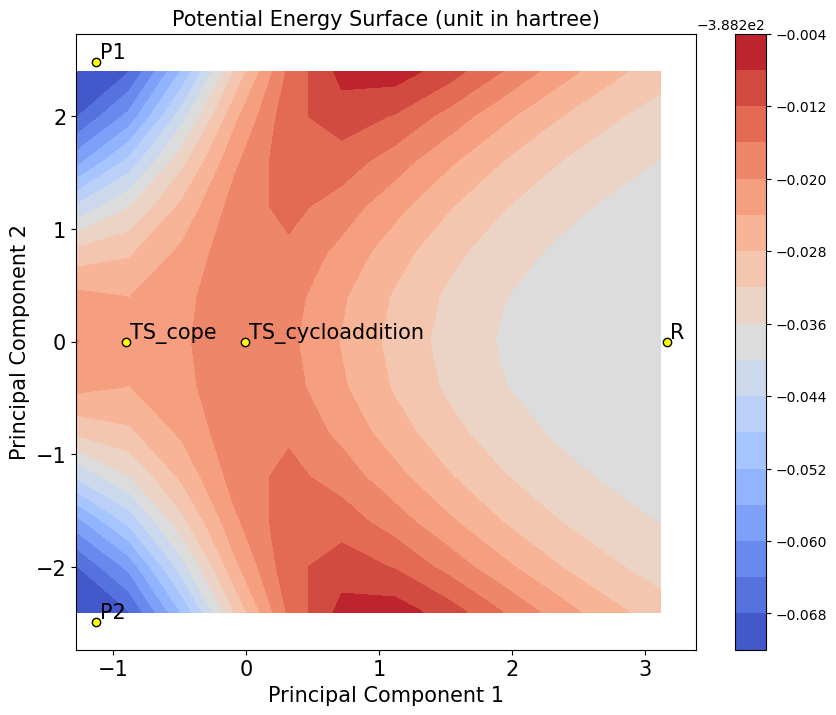

In [22]:
# procedure to construct surface with location of local minima and transition state as saddle point

data = pd.read_excel("data.xlsx")
labels = data['Unnamed: 0']
numeric_data = data.drop(columns = ['Unnamed: 0'])
labels = data.iloc[:, 0]
mean_values = np.around(numeric_data.mean(), decimals=4) #calculate the mean 
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(numeric_data)  # shape: (n_samples, 2)

# Load the PES data
energy_file_path = "energies.xlsx"
data = pd.read_excel(energy_file_path, header=None) #modify here is other energy table is using. 
x = data.iloc[0, 1:].values
y = data.iloc[1:, 0].values
z = data.iloc[1:, 1:].values
# Convert x and y to numeric if needed
x = pd.to_numeric(x, errors='coerce')
y = pd.to_numeric(y, errors='coerce')
# Make meshgrid
X, Y = np.meshgrid(x, y)

# Plot the contour
plt.figure(figsize=(10, 8))
cp = plt.contourf(X, Y, z, levels=20, cmap='coolwarm')
plt.colorbar(cp)

for i, (label, (pc1, pc2)) in enumerate(zip(labels, pca_coords)):
    plt.scatter(pc1, pc2, facecolor="yellow", edgecolor="black")
    plt.text(pc1 + 0.03, pc2 + 0.03, label, fontsize=15, color="black")
    
# Label axes
plt.xlabel('Principal Component 1',fontsize=15)
plt.ylabel('Principal Component 2',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('Potential Energy Surface (unit in hartree)',fontsize=15)
# Save the figure
#plt.savefig("PES_plot.png", dpi=600, bbox_inches="tight") 

plt.show()